In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [12]:
# load the dataset 
from sklearn.datasets import load_breast_cancer
cancer_data= load_breast_cancer()

In [14]:
cancer_data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [18]:
# check the information in the data 
print(cancer_data.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [19]:
# converting the data into Dataframe
df= pd.DataFrame(cancer_data['data'],columns=cancer_data['feature_names'])
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [20]:
# Standardizing the data , to perform PCA 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [21]:
scaler.fit(df)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [25]:
scaled_data=scaler.transform(df)

# Applying PCA 
Basically to achieve Dimentionality Reduction.

In [64]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
# n_components is basically how many dimensions required in the end

In [65]:
data_PCA=pca.fit_transform(scaled_data)

In [66]:
# to check the variene values , Distance from Principle Component and data 
pca.explained_variance_

array([13.30499079,  5.7013746 ])

In [67]:
data_PCA.shape

(569, 2)

Text(0, 0.5, 'Second Principal Component')

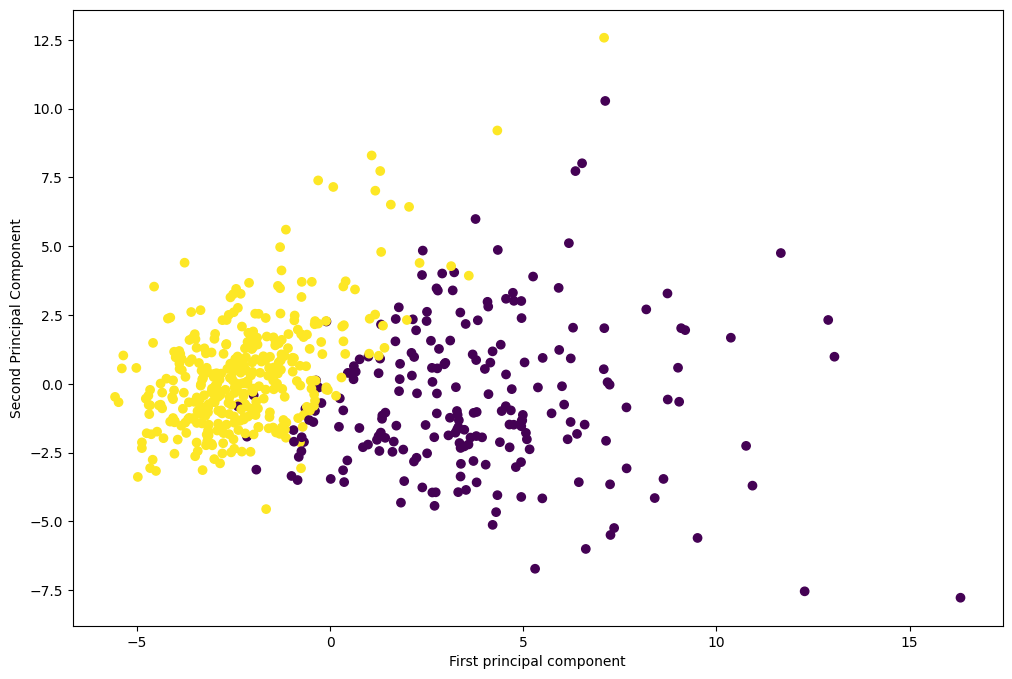

In [68]:
plt.figure(figsize=(12,8))
plt.scatter(data_PCA[:,0],data_PCA[:,1],c=cancer_data['target'])
plt.xlabel('First principal component')
plt.ylabel('Second Principal Component')

<Axes: >

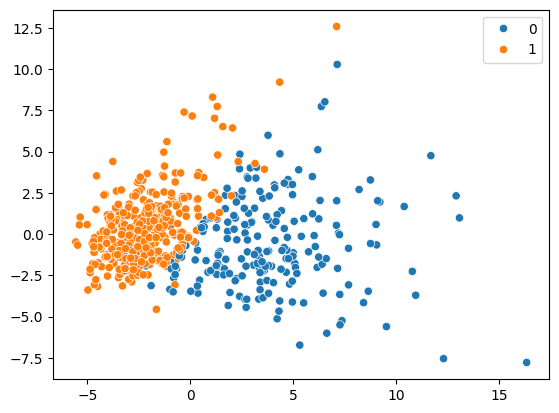

In [69]:
sns.scatterplot(x=data_PCA[:,0],y=data_PCA[:,1],hue=cancer_data['target'])

# PCA for 3 Dimentions

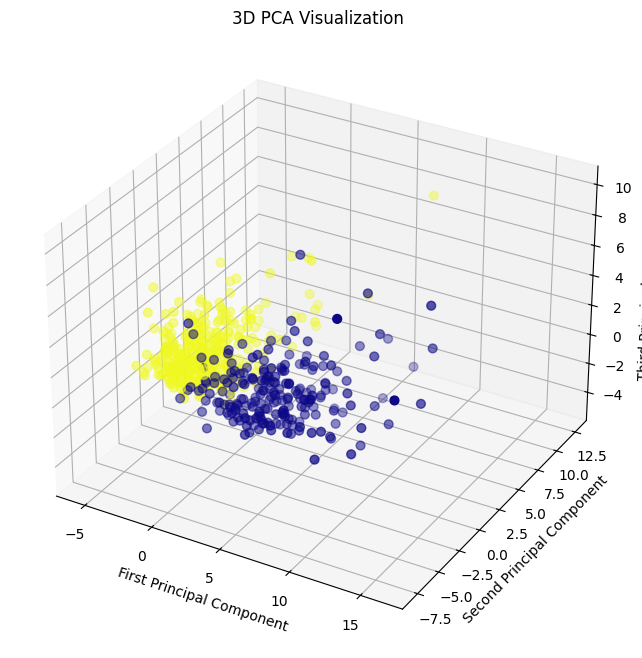

In [55]:
from mpl_toolkits.mplot3d import Axes3D

pca3 = PCA(n_components=3)
data_pca3 = pca3.fit_transform(scaled_data)


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot using the 3 components
# We use the target variable from your notebook (cancer_dataset.target) for coloring
ax.scatter(data_pca3[:, 0], data_pca3[:, 1], data_pca3[:, 2], 
           c=cancer_data['target'], cmap='plasma', s=40)

ax.set_xlabel('First Principal Component')
ax.set_ylabel('Second Principal Component')
ax.set_zlabel('Third Principal Component')
ax.set_title('3D PCA Visualization')

plt.show()

In [74]:
import plotly.express as px

components = pca3.fit_transform(scaled_data)

# Create a DataFrame for Plotly
# We use the feature names 'PC1', 'PC2', 'PC3'
df_pca = pd.DataFrame(data = components, 
                      columns = ['PC1', 'PC2', 'PC3'])

# Add the target labels to the dataframe for coloring
df_pca['label'] = cancer_data['target']
#  names for the legend
df_pca['label'] = df_pca['label'].map({0: 'Malignant', 1: 'Benign'})

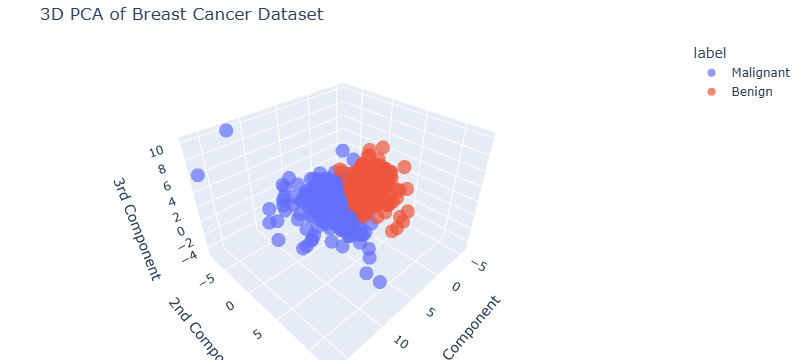

In [75]:
import plotly.express as px
fig = px.scatter_3d(
    df_pca, 
    x='PC1', 
    y='PC2', 
    z='PC3',
    color='label',      # Points colored by diagnosis
    title='3D PCA of Breast Cancer Dataset',
    labels={'PC1': '1st Component', 'PC2': '2nd Component', 'PC3': '3rd Component'},
    opacity=0.7,
    color_discrete_sequence=['#636EFA', '#EF553B'] 
)

# Updated layout for better visibility
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()